In [23]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [24]:
class AgentState(TypedDict):
    name: str
    age: int
    skills: List[str]
    final_result: str

In [25]:
def welcome_message_node(state: AgentState) -> AgentState:
    """Simple message node to welcome the user."""
    state["final_result"] = f"Hello {state['name']}, welcome to the system."
    return state

In [26]:
def user_details_node(state: AgentState) -> AgentState:
    """Simple message node to list user details."""
    state["final_result"] = state["final_result"] + "You are " + state["age"] + " years old!"
    return state

In [27]:
def skills_node(state: AgentState) -> AgentState:
    """Simple message node to list skills."""
    state["final_result"] = state["final_result"] + f" You have skills in: {", ".join(state["skills"])}"
    return state

In [28]:
graph = StateGraph(AgentState)
graph.add_node("welcome", welcome_message_node)
graph.add_edge("welcome", "user")
graph.add_node("user", user_details_node)
graph.add_edge("user", "skills")
graph.add_node("skills", skills_node)
graph.set_entry_point("welcome")
graph.set_finish_point("user")

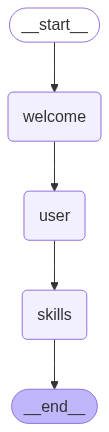

In [29]:
app = graph.compile()
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [30]:
result = app.invoke({"name": "Linda", "age": "31", "skills": ["Python", "Machine Learning", "LangGraph"]})
result["final_result"]

'Hello Linda, welcome to the system.You are 31 years old! You have skills in: Python, Machine Learning, LangGraph'